In [31]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score , recall_score ,f1_score
from sklearn.metrics import classification_report

plt.style.use('dark_background')

# Explore Data

In [32]:
data=pd.read_csv('diabetes.csv')

In [33]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [35]:
data.duplicated().sum()

0

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [38]:
data.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

<AxesSubplot:>

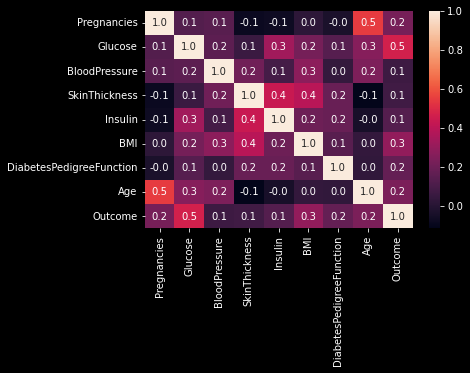

In [39]:
sns.heatmap(data.corr() ,annot=True,fmt='.1f')

<AxesSubplot:xlabel='Outcome', ylabel='count'>

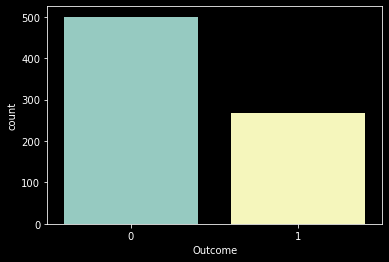

In [40]:
sns.countplot(x='Outcome', data=data)

In [41]:
for i in data.columns:
    fig=px.box(data, x=i ,title=i)
    fig.show()

In [51]:
x=data.drop('Outcome',axis=1)
y=data['Outcome']

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=.8,random_state=42)

In [53]:
mo=LogisticRegression()

In [54]:
mo.fit(x_train,y_train)

LogisticRegression()

In [55]:
pre=mo.predict(x_test)

In [59]:
def all(model):
        model.fit(x_train,y_train)
        pre=model.predict(x_test)
        print(classification_report(pre,y_test))

In [60]:
model1=LogisticRegression()

In [61]:
all(model1)

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        96
           1       0.67      0.64      0.65        58

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.74      0.75      0.75       154



In [62]:
model2=SVC()
all(model2)

              precision    recall  f1-score   support

           0       0.88      0.78      0.83       111
           1       0.56      0.72      0.63        43

    accuracy                           0.77       154
   macro avg       0.72      0.75      0.73       154
weighted avg       0.79      0.77      0.77       154



In [63]:
model3=RandomForestClassifier()
all(model3)

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        96
           1       0.67      0.64      0.65        58

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.74      0.75      0.75       154



In [64]:
model4=GradientBoostingClassifier()
all(model4)

              precision    recall  f1-score   support

           0       0.78      0.81      0.79        95
           1       0.67      0.63      0.65        59

    accuracy                           0.74       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [68]:
lst=[LogisticRegression(),SVC(),RandomForestClassifier(),GradientBoostingClassifier()]
for i in lst:
    def all(i):
        i.fit(x_train,y_train)
        pre=i.predict(x_test)
        print(classification_report(pre,y_test))

In [69]:
from sklearn.metrics import classification_report

lst = [LogisticRegression(), SVC(), RandomForestClassifier(), GradientBoostingClassifier()]

for model in lst:
    print(f"Testing Model: {type(model).__name__}") 
    
    model.fit(x_train, y_train)
    pre = model.predict(x_test)
    
    print(classification_report(y_test, pre)) 
    print("-" * 30)

Testing Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

------------------------------
Testing Model: SVC
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154

------------------------------
Testing Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                 